# LECTURE 18
**Topic:** Periodic Signals in Continuous Time; Sums of Harmonically Related Sinusoids; Introduction to Fourier Series  

---

## Key Points

- Most periodic CT signals can be expressed as sums of Fourier sinusoids (Fourier series).
- Fundamental period $T_0$, fundamental frequency $\omega_0=2\pi/T_0$. The $k$-th Fourier sinusoid: $v^{(k)}(t)=e^{jk\omega_0 t}$.
- Frequency $k\omega_0$ = $k$-th harmonic.
- **Fourier series:** $s(t)=\sum_{k=-\infty}^{\infty}S_k e^{jk\omega_0 t}$
- Real-valued iff $S_{-k}=S_k^*$ for all $k$.


---
## Theory and Examples

### 1. Extension of DFT to Continuous Time

The DFT synthesis equation extended to all $n\in\mathbb{Z}$ gives a periodic sequence. Analogously, most periodic CT signals have a Fourier series.

### 2–4. Continuous-Time Fourier Sinusoids

For period $T_0$, the continuous-time Fourier sinusoids are:
$$v^{(k)}(t)=e^{j\omega_k t}, \quad \omega_k=k\omega_0=\frac{2\pi k}{T_0}, \quad k\in\mathbb{Z}$$

These are the **only** complex sinusoids $e^{j\omega t}$ periodic with period $T_0$.

The positive multiples $2\omega_0,3\omega_0,\ldots$ are called **harmonics** of $\omega_0$.

### 5. Example: Harmonically Related Frequencies

$f_1=50$ Hz and $f_2=87.5$ Hz. Since $f_2/f_1=7/4$ (rational), they share a common fundamental.
The largest common fundamental frequency is $f_0=\gcd(50,87.5)=12.5$ Hz (since $50=4\times 12.5$ and $87.5=7\times 12.5$).


f2/f1 = 87.5/50.0 = 7/4 (rational -> harmonically related)
f0=12.5 Hz: f1=4*f0, f2=7*f0
T0=1/f0=0.0800 sec
Other possible f0 values: f0/2=6.25, f0/3=4.1667, ...

Fourier series coefficients (non-zero):
  S0 = 5.0
  S1 = (S-1)* = 3.1*exp(j*0.3) = 2.9615+0.9161j
  S4 = (S-4)* = 2.3*exp(-j*1.9) = -0.7436-2.1765j
  S7 = (S-7)* = 1.4*exp(j*2.5) = -1.1216+0.8379j


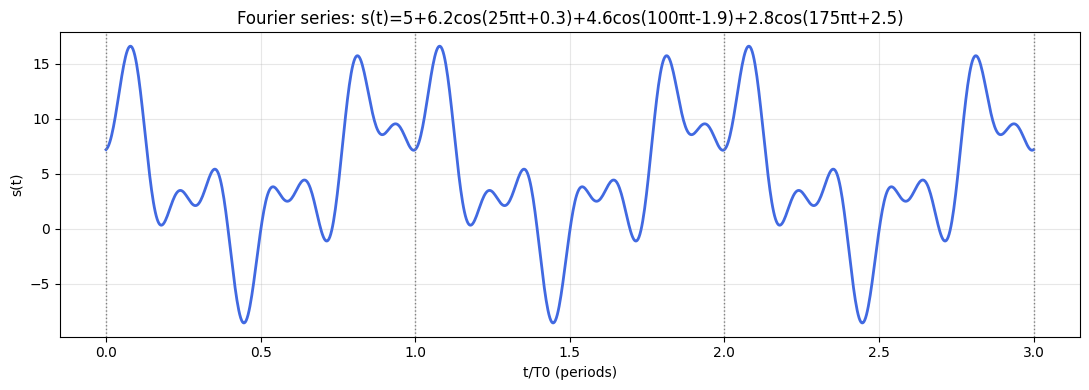

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd

# Harmonically related example
f1=50.0; f2=87.5
ratio=Fraction(f2/f1).limit_denominator(100)
print(f'f2/f1 = {f2}/{f1} = {ratio} (rational -> harmonically related)')
# GCD approach: express as fractions
from math import gcd
# f1=50=4*12.5, f2=87.5=7*12.5, so f0=12.5
f0=12.5
k1=int(f1/f0); k2=int(f2/f0)
print(f'f0={f0} Hz: f1={k1}*f0, f2={k2}*f0')
print(f'T0=1/f0={1/f0:.4f} sec')
print(f'Other possible f0 values: f0/2={f0/2}, f0/3={f0/3:.4f}, ...')
print()

# Example signal from lecture
T0=1/12.5; Omega0=2*np.pi/T0
t=np.linspace(0,3*T0,1000)
s=(5.0+6.2*np.cos(25*np.pi*t+0.3)+4.6*np.cos(100*np.pi*t-1.9)+2.8*np.cos(175*np.pi*t+2.5))

print('Fourier series coefficients (non-zero):')
print(f'  S0 = 5.0')
print(f'  S1 = (S-1)* = 3.1*exp(j*0.3) = {3.1*np.exp(0.3j):.4f}')
print(f'  S4 = (S-4)* = 2.3*exp(-j*1.9) = {2.3*np.exp(-1.9j):.4f}')
print(f'  S7 = (S-7)* = 1.4*exp(j*2.5) = {1.4*np.exp(2.5j):.4f}')

fig,ax=plt.subplots(figsize=(11,4))
ax.plot(t/T0,s,'royalblue',lw=2)
ax.set_xlabel('t/T0 (periods)'); ax.set_ylabel('s(t)')
ax.set_title('Fourier series: s(t)=5+6.2cos(25πt+0.3)+4.6cos(100πt-1.9)+2.8cos(175πt+2.5)')
ax.grid(True,alpha=0.3)
# Mark period
for k in range(4):
    ax.axvline(k,color='gray',ls=':',lw=1)
plt.tight_layout(); plt.show()

---
### 6–8. The Fourier Series

$$s(t)=\sum_{k=-\infty}^{\infty}S_k e^{jk\omega_0 t}$$

- Synthesis equation (sum of complex sinusoids)
- $s(t)$ is periodic with period $T_0$
- Real-valued iff $S_{-k}=S_k^*$ (same as DFT conjugate symmetry)
- $A\cos(\omega t+\phi) = \frac{Ae^{j\phi}}{2}e^{j\omega t} + \frac{Ae^{-j\phi}}{2}e^{-j\omega t}$, so a cosine contributes two complex coefficients

**Example from lecture:**
$$s(t)=5+6.2\cos(25\pi t+0.3)+4.6\cos(100\pi t-1.9)+2.8\cos(175\pi t+2.5)$$
$$S_0=5,\quad S_1=S_{-1}^*=3.1e^{j0.3},\quad S_4=S_{-4}^*=2.3e^{-j1.9},\quad S_7=S_{-7}^*=1.4e^{j2.5}$$

### 9–11. Infinite Fourier Series: Sawtooth Wave

$$s(t)=\sum_{k=1}^{\infty}\frac{2(-1)^{k+1}}{\pi k}\sin(k\omega_0 t)$$

This converges (except at discontinuities) to a sawtooth: $s(t)=2t/T_0$ for $-T_0/2<t<T_0/2$.

Near discontinuities: Gibbs phenomenon — ~9% overshoot that does not vanish as $K\to\infty$.


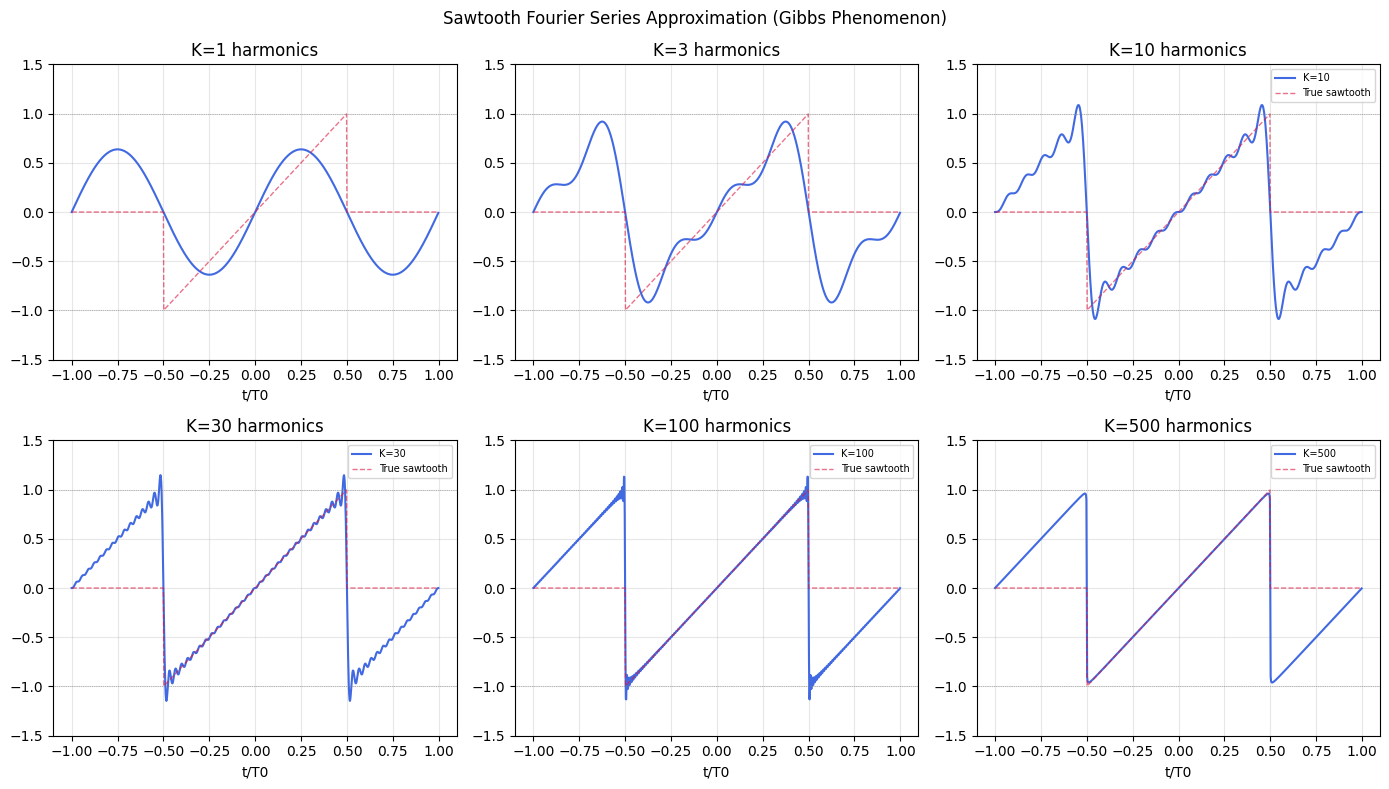

Gibbs overshoot: 0.9713 (true max=1.0, overshoot=-0.0287 = -2.87%)


In [3]:
# Sawtooth wave approximation by finite Fourier series
T0=0.08; N=500
t=np.linspace(-T0,T0-T0/N,2*N)

fig,axes=plt.subplots(2,3,figsize=(14,8))
K_values=[1,3,10,30,100,500]
for ax,K in zip(axes.flat,K_values):
    s=np.zeros_like(t)
    for k in range(1,K+1):
        s+=2*(-1)**(k+1)*np.sin(2*np.pi*k*t/T0)/(np.pi*k)
    # True sawtooth
    s_true=2*t/T0
    s_true=np.where(np.abs(t)<T0/2, s_true, np.sign(t)*0)  # handle endpoints
    ax.plot(t/T0,s,'royalblue',lw=1.5,label=f'K={K}')
    ax.plot(t/T0,s_true,'crimson',lw=1,ls='--',alpha=0.6,label='True sawtooth')
    ax.axhline(1, color='gray',lw=0.5,ls=':'); ax.axhline(-1, color='gray',lw=0.5,ls=':')
    ax.set_title(f'K={K} harmonics'); ax.grid(True,alpha=0.3)
    ax.set_xlabel('t/T0'); ax.set_ylim(-1.5,1.5)
    if K>5: ax.legend(fontsize=7)
plt.suptitle('Sawtooth Fourier Series Approximation (Gibbs Phenomenon)', fontsize=12)
plt.tight_layout(); plt.show()

# Gibbs phenomenon: ~9% overshoot
s_large=np.zeros_like(t)
for k in range(1,1000):
    s_large+=2*(-1)**(k+1)*np.sin(2*np.pi*k*t/T0)/(np.pi*k)
print(f'Gibbs overshoot: {np.max(s_large):.4f} (true max=1.0, overshoot={np.max(s_large)-1:.4f} = {(np.max(s_large)-1)*100:.2f}%)')

---
## Summary

| Concept | Formula |
|---|---|
| Fourier sinusoid | $v^{(k)}(t)=e^{jk\omega_0 t}$ |
| Fundamental freq | $\omega_0=2\pi/T_0=2\pi f_0$ |
| Fourier series | $s(t)=\sum_k S_k e^{jk\omega_0 t}$ |
| Real signal | $S_{-k}=S_k^*$ |
| Cosine → coefficients | $A\cos(k\omega_0 t+\phi)$: $S_k=Ae^{j\phi}/2$, $S_{-k}=Ae^{-j\phi}/2$ |

### Mistakes to Avoid
1. Fourier series has **infinitely many** terms (unlike DFT which has exactly $N$).
2. The harmonic frequencies go in **both** directions: $k=\ldots,-2,-1,0,1,2,\ldots$.
3. Gibbs phenomenon: ~9% overshoot near discontinuities **does not decrease** with more terms.
